In [14]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pandas as pd
import Physicalfunctions as pf
import Physicalparameters as pp

In [15]:
# READ AND CHARGE DATA
df = pd.read_csv("double_pendulum_dataset.csv")
# BUILD t VECTOR
N = len(df)
t = torch.linspace(0, (N-1)*pp.dt, N).view(-1, 1)

# EXCTRACT COLUMNS
theta1 = torch.tensor(df["theta1"].values).view(-1, 1)
theta2 = torch.tensor(df["theta2"].values).view(-1, 1)
omega1 = torch.tensor(df["omega1"].values).view(-1, 1)
omega2 = torch.tensor(df["omega2"].values).view(-1, 1)
alpha1 = torch.tensor(df["alpha1"].values).view(-1, 1)
alpha2 = torch.tensor(df["alpha2"].values).view(-1, 1)

# GROUP
theta_data = torch.hstack((theta1, theta2))
omega_data = torch.hstack((omega1, omega2))
alpha_data = torch.hstack((alpha1, alpha2))

# MEAN AND STD
theta_mean, theta_std = theta_data.mean(0), theta_data.std(0)
omega_mean, omega_std = omega_data.mean(0), omega_data.std(0)
alpha_mean, alpha_std = alpha_data.mean(0), alpha_data.std(0)

# NORMALIZATION
t_min, t_max = t.min(), t.max()
t_norm = (t - t_min) / (t_max - t_min)
theta_norm = (theta_data - theta_mean) / theta_std
omega_norm = (omega_data - omega_mean) / omega_std
alpha_norm = (alpha_data - alpha_mean) / alpha_std
dt_scale = (t_max - t_min)


In [ ]:
model = pf.PINN_DoublePendulum()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)
 # Escalado temporal
dt_scale = (t_max - t_min)

for epoch in range(pp.num_epochs):
    t_batch = t_norm
    theta_batch = theta_norm
    omega_batch = omega_norm
    alpha_batch = alpha_norm
    t_batch.requires_grad_(True)
    
    optimizer.zero_grad()
    
    # =========================
    # Forward + derivadas
    # =========================
    theta_pred, dtheta_pred, d2theta_pred = pf.time_derivatives(model, t_batch)
    
   
    
    omega_pred = dtheta_pred / dt_scale
    alpha_pred = d2theta_pred / (dt_scale**2)
    # DESNORMALIZACIÓN (clave para física + energía
    theta_real = theta_pred * theta_std + theta_mean
    omega_real = omega_pred * omega_std + omega_mean

    # LOSS DE DATOS (NORMALIZADOS)
    loss_theta = torch.mean((theta_pred - theta_batch)**2)
    loss_omega = torch.mean((omega_pred - omega_batch)**2)
    loss_alpha = torch.mean((alpha_pred - alpha_batch)**2)
    
    
    loss_data = loss_theta + 0.1 * loss_omega + 0.01 * loss_alpha
    
    # =========================
    # LOSS FÍSICO (CORRECTO)
    # =========================
    loss_phys = pf.physical_loss(
        theta_pred, dtheta_pred, d2theta_pred,
        t_min, t_max, pp.params,
        theta_mean, theta_std,
        omega_mean, omega_std,
        alpha_mean, alpha_std
    )
    # LOSS ENERGÍA
    loss_energy = pf.energy_loss(theta_real, omega_real, pp.params)

    # =========================
    # LOSS TOTAL
    # =========================
    lambda_phys = torch.tensor(0.0)
    if epoch >1000:
        lambda_energy = 0.01
    else:
        lambda_energy = 0.0
    if epoch > 750:
        ramp = min(1.0, (epoch - 750)/750)
        lambda_phys = ramp * (loss_data.detach() / (loss_phys.detach() + 1e-6))
        lambda_phys = torch.clamp(lambda_phys, 0.0, 10)
        loss = loss_data + lambda_phys * loss_phys +  lambda_energy * loss_energy
    else:
        loss = loss_data
    
    # BACKPROP
   
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()
    

    
    scheduler.step()

    # =========================
    # LOGGING
    # =========================
    if epoch % 100 == 0:
        print(f"Epoch {epoch}")
        print(f"Total Loss: {loss.item():.6f}")
        print(f"Data Loss: {loss_data.item():.6f}")
        print(f"Physics Loss: {loss_phys.item():.6f}")
        print(f"lambda_phys: {lambda_phys.item() if epoch > 1000 else 0}")


Epoch 0
Total Loss: 1.112374
Data Loss: 1.112374
Physics Loss: 77.903846
lambda_phys: 0
Epoch 100
Total Loss: 1.099934
Data Loss: 1.099934
Physics Loss: 93.228041
lambda_phys: 0
Epoch 200
Total Loss: 1.099657
Data Loss: 1.099657
Physics Loss: 92.197191
lambda_phys: 0
Epoch 300
Total Loss: 1.100461
Data Loss: 1.100461
Physics Loss: 94.114260
lambda_phys: 0
Epoch 400
Total Loss: 1.100434
Data Loss: 1.100434
Physics Loss: 93.629060
lambda_phys: 0
Epoch 500
Total Loss: 1.097576
Data Loss: 1.097576
Physics Loss: 93.072036
lambda_phys: 0
Epoch 600
Total Loss: 1.097675
Data Loss: 1.097675
Physics Loss: 93.431233
lambda_phys: 0
Epoch 700
Total Loss: 1.089484
Data Loss: 1.089484
Physics Loss: 85.858213
lambda_phys: 0
Epoch 800
Total Loss: 1.194776
Data Loss: 1.115751
Physics Loss: 91.086667
lambda_phys: 0
Epoch 900
Total Loss: 1.363494
Data Loss: 1.136109
Physics Loss: 57.800305
lambda_phys: 0
Epoch 1000
Total Loss: 1.527323
Data Loss: 1.144845
Physics Loss: 95.715856
lambda_phys: 0
Epoch 1100


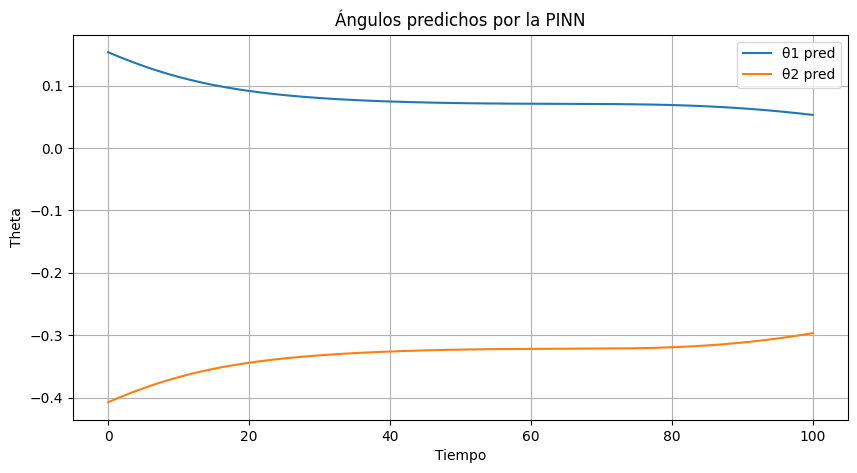

In [ ]:
model.eval()

# =========================
# PREDICCIÓN
# =========================
t_norm.requires_grad_(True)

theta_pred, _, _ = pf.time_derivatives(model, t_norm)

# =========================
# DESNORMALIZAR
# =========================
theta_pred_real = theta_pred * theta_std + theta_mean

# =========================
# A NUMPY
# =========================
t_np = t.detach().cpu().numpy()
theta_pred_np = theta_pred_real.detach().cpu().numpy()

# =========================
# PLOT (SOLO PREDICCIÓN)
# =========================
plt.figure(figsize=(10,5))

plt.plot(t_np, theta_pred_np[:,0], label="θ1 pred")
plt.plot(t_np, theta_pred_np[:,1], label="θ2 pred")

plt.title("Ángulos predichos por la PINN")
plt.xlabel("Tiempo")
plt.ylabel("Theta")
plt.legend()
plt.grid()

plt.show()